# Visualizations for paper figures

General-purpose notebook for narrow, publication-sized plots meant to sit
side-by-side in the ACM two-column template (as opposed to the wide
single-figure diagnostic plots under `results/`).


In [ ]:
from pathlib import Path
import sys

ROOT = Path(".").resolve().parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "steady_state_detection"))  # for ssd_trim.run_ssd_trim

import matplotlib.pyplot as plt
import pm4py

from time_series_preprocessing import ts_splits_from_log

OUT_DIR = Path(".").resolve()

log = pm4py.read_xes(str(ROOT / "data" / "real-life" / "bpic20-dom.xes"))

In [2]:

_BASE = dict(trim_pct=0.25, trim_k=1.5, trim_frac=0.6, trim_window=7,
             train_frac=0.7, val_frac=0.1, cut_date=None)

splits_none    = ts_splits_from_log(log, **{**_BASE, "trim_method": None})

cc_none    = splits_none["concurrent_cases"]


from ssd_trim import run_ssd_trim
from time_series_preprocessing import Split3WayConfig, split_timeseries

_ssd_result = run_ssd_trim(log, window_step="D")
_full_cc_raw = splits_none["concurrent_cases"]["raw"]
_canonical_end = _ssd_result["cutoff"] if _ssd_result["cutoff"] is not None else _full_cc_raw.index[-1]
_cc_trimmed_ssd = _full_cc_raw[_full_cc_raw.index <= _canonical_end]
_split_cfg = Split3WayConfig(train_frac=_BASE["train_frac"], val_frac=_BASE["val_frac"],
                             test_frac=1 - _BASE["train_frac"] - _BASE["val_frac"])
_, _, _, _train_split_ssd, _val_split_ssd = split_timeseries(_cc_trimmed_ssd, _split_cfg)

_idx = _cc_trimmed_ssd.index
_lo = _train_split_ssd.tz_convert(None) if _idx.tz is None else _train_split_ssd
_hi = _val_split_ssd.tz_convert(None) if _idx.tz is None else _val_split_ssd
cc_ssd = {
    "raw": _full_cc_raw, "trimmed": _cc_trimmed_ssd,
    "train": _cc_trimmed_ssd[_idx <= _lo],
    "val": _cc_trimmed_ssd[(_idx > _lo) & (_idx <= _hi)],
    "test": _cc_trimmed_ssd[_idx > _hi],
    "train_split": _train_split_ssd, "val_split": _val_split_ssd,
}

In [3]:
import matplotlib.dates as mdates


def plot_timeseries_splits_narrow(raw, trimmed, train, val, test, save_path=None,
                                   figsize=(6.5, 4)):
    """Half-width version of pipeline_real.ipynb's plot_timeseries_splits
    (figsize=(13, 4)) — same colors/markers, meant to sit two-up in an ACM
    two-column layout instead of spanning a full column on its own. Saves
    vector PDF (no dpi needed) instead of the diagnostic PNGs under results/.
    No title — the paper caption carries that; larger bold fonts throughout
    so labels stay legible at half-column width. X-ticks are thinned out and
    rotated since bold digits are wider than the regular-weight ones the
    default tick spacing was tuned for."""
    truncated = raw.loc[raw.index > trimmed.index[-1]]
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(train.index, train, color="steelblue", label="train")
    ax.plot(val.index,   val,   color="orange",    label="val")
    ax.plot(test.index,  test,  color="green",     label="test")
    if len(truncated):
        ax.plot(truncated.index, truncated, color="gray", linestyle="--",
                alpha=0.7, label="truncated")
        ax.axvline(truncated.index[0], linestyle=":", color="gray", linewidth=1)
    ax.axvline(train.index[-1], linestyle=":", color="gray", linewidth=1)
    ax.axvline(val.index[-1],   linestyle=":", color="gray", linewidth=1)
    ax.set_ylabel("Concurrent cases", fontsize=14, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=5))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.tick_params(axis="both", labelsize=12)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    ax.legend(fontsize=11, prop={"weight": "bold", "size": 11})
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    return fig

/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:29: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:30: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  for lbl in ax.get_xticklabels() + ax.get_yticklabels():
/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:33: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  plt.tight_layout()
/var/fol

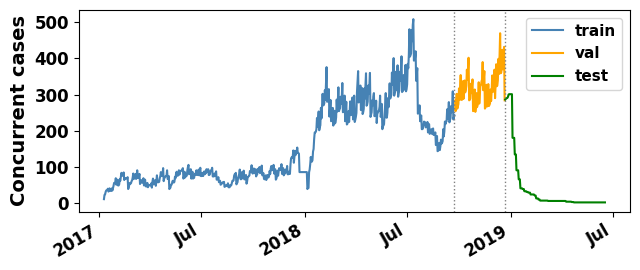

In [4]:
fig_none = plot_timeseries_splits_narrow(
    cc_none["raw"], cc_none["trimmed"], cc_none["train"], cc_none["val"], cc_none["test"],
    save_path=OUT_DIR / "bpic20-dom_none_concurrent_cases_splits.pdf",
    figsize=(6.5, 2.8),
)

/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:29: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:30: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  for lbl in ax.get_xticklabels() + ax.get_yticklabels():
/var/folders/19/xvc3hgl123v3myrcq9dl01cm0000gn/T/ipykernel_36886/1231775076.py:33: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  plt.tight_layout()
/var/fol

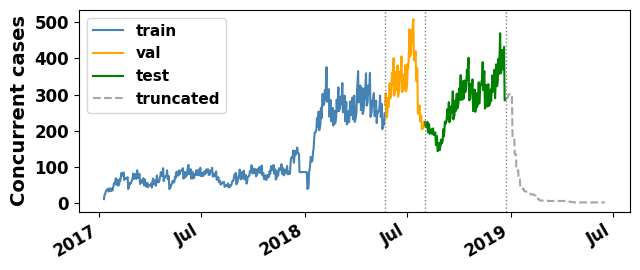

In [5]:
fig_ssd = plot_timeseries_splits_narrow(
    cc_ssd["raw"], cc_ssd["trimmed"], cc_ssd["train"], cc_ssd["val"], cc_ssd["test"],
    save_path=OUT_DIR / "bpic20-dom_ssd_concurrent_cases_splits.pdf",
    figsize=(6.5, 2.8),
)
